# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [93]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [94]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [95]:
plans.head(5) # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [96]:
users.head(5) # mostrar las primeras 5 filas de users

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra


In [97]:
usage.head(5) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [98]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (500, 8)
usage (40000, 6)


In [99]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [100]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   age         500 non-null    int64 
 2   churn_date  38 non-null     object
 3   city        500 non-null    object
 4   first_name  500 non-null    object
 5   last_name   500 non-null    object
 6   reg_date    500 non-null    object
 7   tariff      500 non-null    object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [101]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [102]:


# cantidad de nulos para users
print(users.isnull().sum()) # Cantidad de valores nulos)
print(users.isna().mean().sort_values(ascending=False)) # Proporción de valores nulos)



user_id         0
age             0
churn_date    462
city            0
first_name      0
last_name       0
reg_date        0
tariff          0
dtype: int64
churn_date    0.924
user_id       0.000
age           0.000
city          0.000
first_name    0.000
last_name     0.000
reg_date      0.000
tariff        0.000
dtype: float64


In [103]:
print(usage.isnull().sum())
print(usage.isna().mean().sort_values(ascending=False)) # cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
duration    0.55190
length      0.44740
date        0.00125
id          0.00000
user_id     0.00000
type        0.00000
dtype: float64


#### ✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
Los valos de user_id en ambos datasets no coinciden, si bien las dos columnas se llaman igual y corresponden al mimo tipo de datos, no coinicden si queremos unirlas a través de este

**Users**
- El dataset muestra valores nulos en la columna churn_date, que se refiere a la fecha de baja, los valores nulos representan el 92.4% del total, en este caso se **conserva** ya que puede significar que el cliente está activo, no necesariamente que hubo errores u omisiones.

**usage**
- El dataset presenta valores nulos en 3 de sus columnas:
- Duration con el 55.19% **se investigan**
- length con el 44.7% **se investigan** tanto duration como length se investigan para ver si los faltantes son llamadas realizadas y no contestadas, las coincidentes entre estas columnas de imputan con 0. 
- date con el 0.12 %, **se eliminan los nulos**

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [104]:
users.describe() # explorar columnas numéricas de users

,user_id,age
count,500.000000,500.00000
mean,1249.500000,46.58800
std,144.481833,16.66763
min,1000.000000,18.00000
25%,1124.750000,32.00000
50%,1249.500000,46.00000
75%,1374.250000,62.00000
max,1499.000000,75.00000


- La columna `user_id`. La media y el segundo cuartil muestran la misma medida, no hay mucha variación a los extremos, por el contrario, se identifica una concentración alrededor del promedio. 
- La columna `age` muestra un rango de edad de entre 18 a 75 años, no hay mucha variación entre la media y el segundo cuartil. De manera previa, se identifica una concentración alrededor del promedio y de rango estrecho.

In [105]:
usage.describe() # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` muestar el mismo recuento de datos, a diferencia de duration y lehngth, debido a que las llamadas pudieron realizarse, pero no contestarse. Para el caso de id, se muestra un rango amplio de valores extremos, aunque la media y el segundo cuartil coinciden. mientras que user_id muestra una dispersión moderada en este caso varia la media del segundo cuartil.
- Las columnas duration y length presentan menos valores en relación con id y user_id. en cuanto a duración se consideran valores de 0 (posiblemente llamadas realizadas pero no atendidas) y el máximo de 120, la media y el segundo cuartil no coinciden, siendo la media más alta, esto puede deberse a la amplitud de rangos y a posibles valores atípicos, sin embargo, son pocos los valores que llegan al máximo. En cuanto a lenght la media y el segundo cuartil son casi los mismos, aunque la desviación estandar es alta, es decir,con mucha variabilidad.  debido al minimo (0) y al máximo (1490)se puede identificar un rango amplio y con posibles outliers. 

In [106]:
# explorar columnas categóricas de users
columnas_user = users[['city', 'tariff']].describe(include='object')
print(columnas_user)


          city tariff
count      500    500
unique      76      2
top     Москва  smart
freq        99    351


- La columna `city` cuenta con 500 datos no nulos, 76 variables únicas, siendo la principal Mockba, con una frecuencia de 99.
- La columna `plan` cuenta con 500 datos no nulos, únicamente dos valores siendo el principal smart, con una frecuencia de 351.

In [107]:
# explorar columna categórica de usage
usage[['type']].describe() # completa el código

,type
count,40000
unique,2
top,text
freq,22092


- La columna `type`con un total de 40,000 valores no nulos, solo dos variables siendo la principal text con 22092 valores. 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  en cuando a las columnas duración y length se identifican bastantes valores en 0, como se menciona anteriormente, pueden ser llamadas que se realizaron, pero no se contestaron. 
- ¿Qué acción tomarías?  Estos valores se conservan para el análisis, pues significan un dato adicional, asimismo, borrarlos eliminaría gran parte de los datos, sesgando el análisis. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [108]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date']) # completa el código

In [109]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date']) # completa el código

In [110]:

# Revisar los años presentes en `reg_date` de users
users['reg_date'].describe()

count                     500
unique                    270
top       2018-05-28 00:00:00
freq                        8
first     2018-01-01 00:00:00
last      2018-12-31 00:00:00
Name: reg_date, dtype: object

En `reg_date` únicamente se ubican datos del 2018, considerando que la descripción inicial del dataset establecía que eran datos hasta el 2024, quedan años pendientes para poder analizar con otros datasets que sí incluyen los demás años. Se identifican fechas repetidas. 

In [111]:
# Revisar los años presentes en `date` de usage
usage['date'].describe()


count                             39950
unique                            39950
top       2024-06-16 13:26:59.770494262
freq                                  1
first               2024-01-01 00:00:00
last                2024-06-30 00:00:00
Name: date, dtype: object

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Unicamente tenemos fechas del primero de enero al 30 de junio, es decir, del primer semestre del año. No se identifican datos fechas repetidas. 

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos) Si, en el dataset usrs únicamente encontramos datos del 2018, mientras que en el dataset usage únicamente hay información sobre el primer semestre del 2024. Se requiere de la información completa en caso de que se requiera anailizar los dos dataset. 
- ¿Qué harías con ellas?

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [112]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].mean()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    500.00000
mean      46.58800
std       16.66763
min       18.00000
25%       32.00000
50%       46.00000
75%       62.00000
max       75.00000
Name: age, dtype: float64

In [113]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].describe()

count        500
unique        76
top       Москва
freq          99
Name: city, dtype: object

In [114]:
# Marcar fechas futuras como NA para reg_date
fechas_futuras= users['reg_date'] > pd.Timestamp.now()
users.loc[fechas_futuras, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                     500
unique                    270
top       2018-05-28 00:00:00
freq                        8
first     2018-01-01 00:00:00
last      2018-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [115]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration_flag"]=usage["duration"].isna().astype(int)


In [116]:
# Verificación MAR en usage (Missing At Random) para length
usage["length_flag"]=usage["length"].isna().astype(int)

In [117]:
usage.groupby('type')[['duration_flag','length_flag']].mean()

,duration_flag,length_flag
type,,
call,0.000000,0.99933
text,0.999276,0.00000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Son valores faltantes MAR, esto se debe a que la ausencia de una columna se puede explicar con otra, ya que las llamadas tienen nulos en la longitud y los textos tienen nulos en la duración. Asimismo, estos datos deben conservarse, sin corregir ni borrar, ya que esto significaría cambios considerables en el análisis. Son nulos esperados debido a las características del dato. 

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [118]:
# Columnas auxiliares
usage["cant_mensajes"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["cant_llamadas"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
usage["cant_minutos_llamada"] = np.where(usage["type"] == "call",usage["duration"], 0)
usage["cant_longitud_mensaje"] = np.where(usage["type"] == "text",usage["length"], 0)

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({"cant_mensajes": "sum", "cant_llamadas":"sum","cant_minutos_llamada":"sum", "cant_longitud_mensaje": "sum"}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,cant_longitud_mensaje
0,10000,7,3,23.70,258.0
1,10001,5,10,33.18,226.0
2,10002,5,2,10.74,225.0


In [119]:
# Renombrar columnas, No aplica, ya que se elaboró el diccionario en la parte superior

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,cant_longitud_mensaje
0,10000,7,3,23.70,258.0
1,10001,5,10,33.18,226.0
2,10002,5,2,10.74,225.0


In [120]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users,usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,cant_mensajes,cant_llamadas,cant_minutos_llamada,cant_longitud_mensaje
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,NaN,NaN,NaN,NaN
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart,NaN,NaN,NaN,NaN
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart,NaN,NaN,NaN,NaN
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra,NaN,NaN,NaN,NaN
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra,NaN,NaN,NaN,NaN


In [121]:
user_profile['cant_mensajes'].isnull().sum()

500

In [122]:
(usage['user_id'] - 9000).describe()

count    40000.000000
mean      3002.405975
std       1157.279564
min       1000.000000
25%       1996.000000
50%       3013.000000
75%       4005.000000
max       4999.000000
Name: user_id, dtype: float64

In [123]:
users['user_id'].describe()

count     500.000000
mean     1249.500000
std       144.481833
min      1000.000000
25%      1124.750000
50%      1249.500000
75%      1374.250000
max      1499.000000
Name: user_id, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [124]:

# Resumen estadístico de las columnas numéricas
user_profile.describe()


,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada,cant_longitud_mensaje
count,500.000000,500.00000,0.0,0.0,0.0,0.0
mean,1249.500000,46.58800,NaN,NaN,NaN,NaN
std,144.481833,16.66763,NaN,NaN,NaN,NaN
min,1000.000000,18.00000,NaN,NaN,NaN,NaN
25%,1124.750000,32.00000,NaN,NaN,NaN,NaN
50%,1249.500000,46.00000,NaN,NaN,NaN,NaN
75%,1374.250000,62.00000,NaN,NaN,NaN,NaN
max,1499.000000,75.00000,NaN,NaN,NaN,NaN


In [125]:
# Distribución porcentual del tipo de plan
user_profile["tariff"].value_counts(normalize=True)

smart    0.702
ultra    0.298
Name: tariff, dtype: float64

In [126]:
user_profile.columns

Index(['user_id', 'age', 'churn_date', 'city', 'first_name', 'last_name',
       'reg_date', 'tariff', 'cant_mensajes', 'cant_llamadas',
       'cant_minutos_llamada', 'cant_longitud_mensaje'],
      dtype='object')

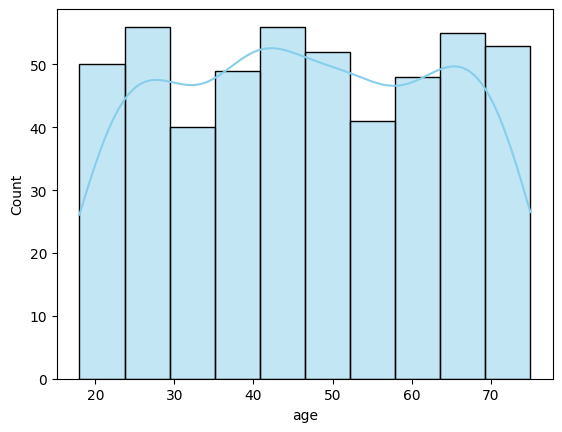

In [127]:
# Histograma para visualizar la edad (age)
sns.histplot(user_profile["age"], bins=10, color='skyblue', kde=True)
plt.show()


💡Insights: 
- Distribución No hay diferencias entre la distribución de edades, si bien se refiere a personas mayores de edad, no se identifican edades que tengan poco o mucho uso. 

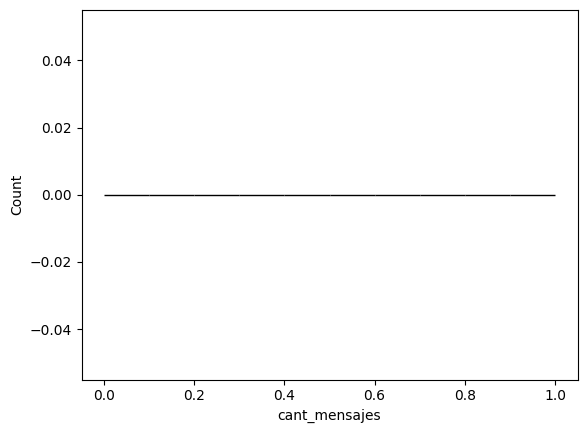

In [128]:
# Histograma para visualizar la cant_mensajes

sns.histplot(user_profile["cant_mensajes"], bins=10, color='skyblue')
plt.show()


💡Insights: 
-el hitograma se ve así debido ala falta de coincidencia entre los columnas de user_ id que se expuso anteriormente, ya que solo tiene valores NAN.

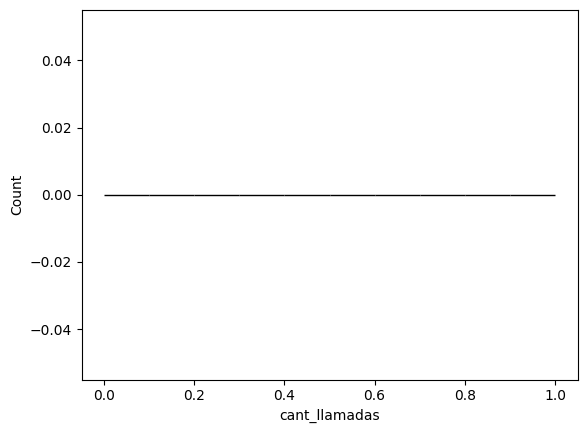

In [129]:
# Histograma para visualizar la cant_llamadas
sns.histplot(user_profile["cant_llamadas"], bins=10, color='skyblue')
plt.show()


💡Insights: 
- Distribución Mismo caso que el anterior

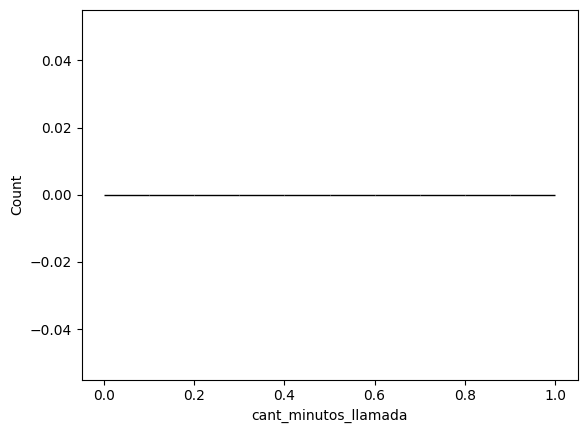

In [130]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile["cant_minutos_llamada"], bins=10, color='skyblue')
plt.show()


💡Insights: 
- ...Mismo caso debido a la incoincidencia de columnas en user_id

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

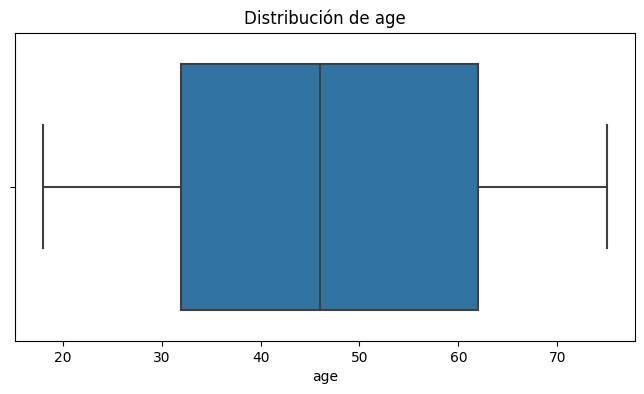

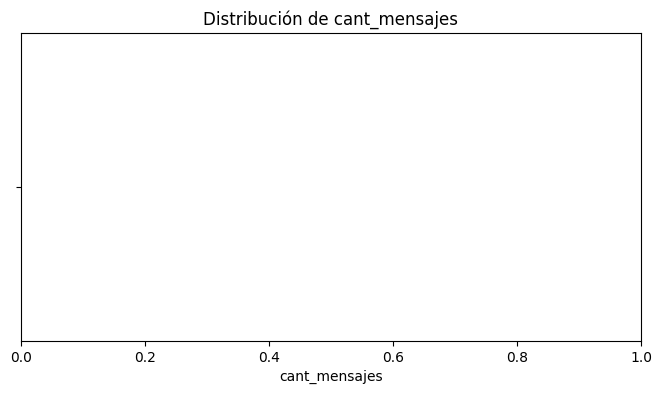

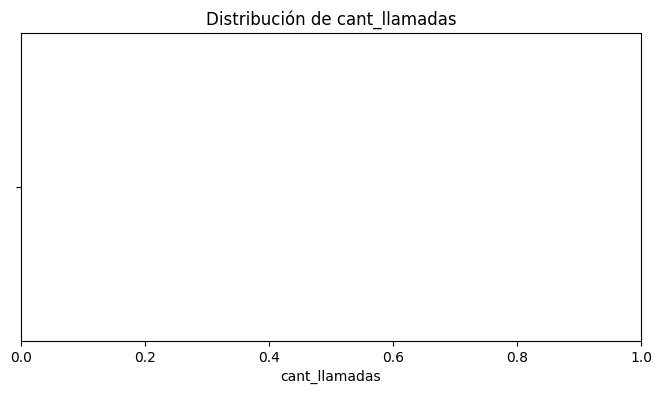

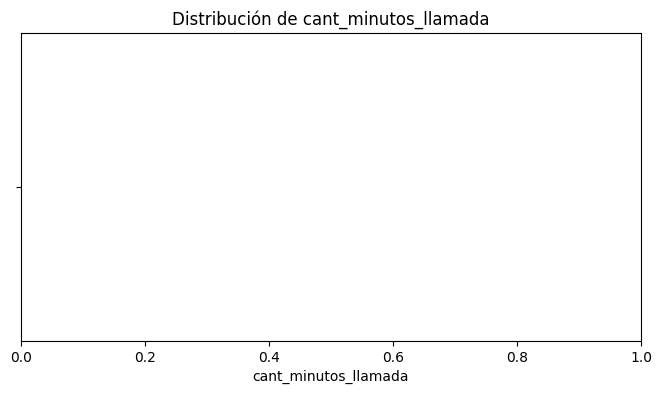

In [132]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col])  
    plt.title(f'Distribución de {col}') 
    plt.xlabel(col)
    plt.show() 

💡Insights: 
- Age: no presenta outliers
- cant_mensajes: 
- cant_llamadas: 
- cant_minutos_llamada: Debido al tema de las columnas no coincidentes en user_id, no se pueden identificar las características. 

In [141]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

Q1= user_profile[columnas_limites].quantile(0.25)
print("primer cuartil:", Q1)

Q3= user_profile[columnas_limites].quantile(0.75)
print("tercer cuartil:", Q3)



primer cuartil: age                     32.0
cant_mensajes            NaN
cant_llamadas            NaN
cant_minutos_llamada     NaN
Name: 0.25, dtype: float64
tercer cuartil: age                     62.0
cant_mensajes            NaN
cant_llamadas            NaN
cant_minutos_llamada     NaN
Name: 0.75, dtype: float64


In [142]:
IQR = Q3-Q1
print("IQR:",IQR)

IQR: age                     30.0
cant_mensajes            NaN
cant_llamadas            NaN
cant_minutos_llamada     NaN
dtype: float64


In [143]:
lower=Q1-1.5*IQR
print("limite inferior:", lower)

upper= Q3+1.5*IQR
print("limite superior:", upper)

limite inferior: age                    -13.0
cant_mensajes            NaN
cant_llamadas            NaN
cant_minutos_llamada     NaN
dtype: float64
limite superior: age                     107.0
cant_mensajes             NaN
cant_llamadas             NaN
cant_minutos_llamada      NaN
dtype: float64


In [137]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,500.00000,0.0,0.0,0.0
mean,46.58800,NaN,NaN,NaN
std,16.66763,NaN,NaN,NaN
min,18.00000,NaN,NaN,NaN
25%,32.00000,NaN,NaN,NaN
50%,46.00000,NaN,NaN,NaN
75%,62.00000,NaN,NaN,NaN
max,75.00000,NaN,NaN,NaN


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué? Para estas tres columnas está el mismo problema que se le antecede a la incompatibilidad entre columnas user_id- En lo que respecta a Age, no se identifican outliers, pues el rango de edas corresponde a 18-75 años. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [154]:
# Crear columna grupo_uso
user_profile["grupo_uso"] = 
np.where((user_profile["cant_llamadas"]<5)&(user_profile["cant_mensajes"]<5), "Bajo uso",
           np.where((user_profile["cant_llamadas"]<10)&(user_profile["cant_mensajes"]<10), "Uso medio", "Alto uso"))


In [155]:
# verificar cambios
user_profile.head()

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,cant_mensajes,cant_llamadas,cant_minutos_llamada,cant_longitud_mensaje,grupo_uso
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,NaN,NaN,NaN,NaN,Alto uso
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart,NaN,NaN,NaN,NaN,Alto uso
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart,NaN,NaN,NaN,NaN,Alto uso
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra,NaN,NaN,NaN,NaN,Alto uso
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra,NaN,NaN,NaN,NaN,Alto uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [156]:
# Crear columna grupo_edad
user_profile["grupo_edad"] = np.where((user_profile["age"]<30), "Joven",
           np.where((user_profile["age"]<60), "Adulto", "Adulto mayor"))

In [157]:
# verificar cambios
user_profile.head()

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,cant_mensajes,cant_llamadas,cant_minutos_llamada,cant_longitud_mensaje,grupo_uso,grupo_edad
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,NaN,NaN,NaN,NaN,Alto uso,Adulto
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart,NaN,NaN,NaN,NaN,Alto uso,Adulto
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart,NaN,NaN,NaN,NaN,Alto uso,Adulto
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra,NaN,NaN,NaN,NaN,Alto uso,Joven
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra,NaN,NaN,NaN,NaN,Alto uso,Adulto mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

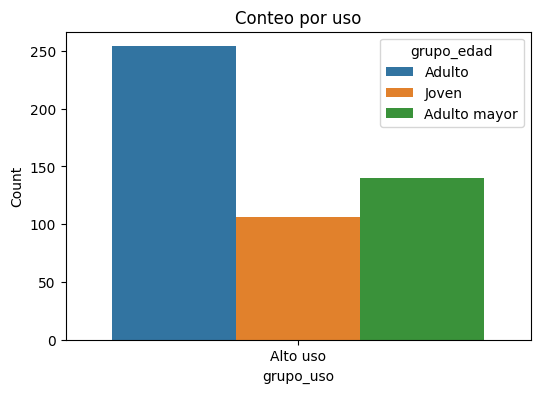

In [167]:

# Visualización de los segmentos por uso

plt.figure(figsize=(6, 4))
sns.countplot(data=user_profile, x="grupo_uso", hue="grupo_edad")
plt.xlabel("grupo_uso")
plt.ylabel("Count")
plt.title("Conteo por uso")
plt.show()



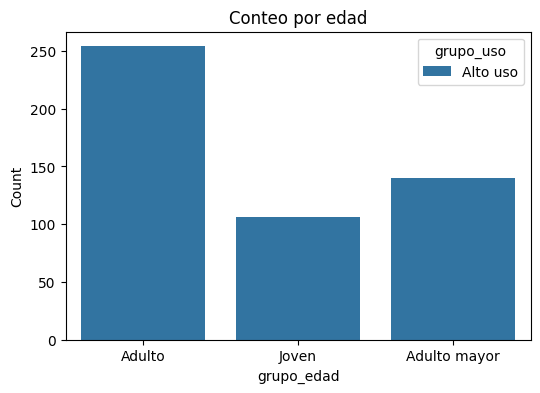

In [166]:

plt.figure(figsize=(6, 4))
sns.countplot(data=user_profile, x="grupo_edad", hue="grupo_uso")
plt.xlabel("grupo_edad")
plt.ylabel("Count")
plt.title("Conteo por edad")
plt.show()




---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- El principal problema detectado fue la incompatibilidad de las columnas user_id entre los dataset users y usage, ya que, si bien esta columna se encontraba en los datasets, los id no coincidían y esto impactó en el análisis. Como tal no fue un error de captura, simplemente los parámetros para definir el user_id fueron distintos. 
- En cuanto a datos faltantes, en las columnas duration y length se identificaron varios valores nulos, sin embargo, esto no corresponde a un error, simplemente que el tipo de dato no se podía medir igual, es decir, las llamadas  no podían dar una longitud (caracteres) y el texto no podía dar una duración (tiempo), sin embargo, corregir o borrar los datos ocasionaría la pérdida de información de relevancia. 


🔍 **Segmentos por Edad**
- En cuanto a la edad, esta no presentaba outliers, 
- En términos de uso, el grupo de adultos son el principal grupo, pasando posteriormente a los adultos mayores y los jóvenes. 


📊 **Segmentos por Nivel de Uso**
- Debido al problema antes mencnionado, no se puede identificar un conteo en el uso. 

➡️ Esto sugiere que el problema impidió un análisis completo de los datos, pues no se pudo generar una coincidencia entre los datasets. 


💡 **Recomendaciones**
- En caso de ser posible, obtener una columna de coincidencia o verificar la lógica sobre la categorización del user_id. 
- abc 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---


Agrega un archivo `README.md` que describa de forma clara:

- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.


---

Link a repositorio público del proyecto: `LINK a tu repo aquí`